# Class imbalance and EDA — Bank Marketing, Default of Credit Card Clients, Credit Card Fraud
**Haasita | follow-up to the 2 October mentor meeting**

Scope: class imbalance and data-structure EDA for the three datasets in the agentic GAN project. Baseline modelling is handled elsewhere and is not done here.

| Dataset | Source | Role in the project |
|---|---|---|
| Bank Marketing | UCI id 222 | Primary dataset, mixed tabular, target = 1 is ~12% of rows (CTGAN) |
| Default of Credit Card Clients | UCI id 350 | Moderate imbalance, 6 months of history (TimeGAN candidate) |
| Credit Card Fraud | Kaggle `mlg-ulb/creditcardfraud` | Extreme imbalance, PCA-transformed features |

Conventions follow `Bank_Marketing_EDA.ipynb`: stratified 60/20/20 split with seed 42 first, and all profiling on the training split only. Held-out splits get label-balance and overlap audits only.

Run from the `eda/` folder. Install: `pip install pandas numpy matplotlib seaborn scipy scikit-learn ucimlrepo kagglehub jupyter`. Outputs go to `output/eda_ph7/` (git-ignored).

**Fraud data:** place Kaggle's `creditcard.csv` at `output/data/creditcard.csv`. If it is absent, the notebook downloads it with `kagglehub` (no Kaggle login needed for this public dataset). The OpenML copy is not used because it lacks the `Time` column.

In [1]:
from pathlib import Path
import os, json, hashlib
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.mplconfig'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
OUT = Path('output/eda_ph7'); OUT.mkdir(parents=True, exist_ok=True)
DATA = Path('output/data'); DATA.mkdir(parents=True, exist_ok=True)
SEED = 42
COL = {'neg': '#355C7D', 'pos': '#E59036'}

def savefig(name):
    plt.savefig(OUT / f'{name}.png', dpi=160, bbox_inches='tight')
    plt.show(); plt.close()

def table(df, name, **kw):
    df.to_csv(OUT / f'{name}.csv', index=True)
    display(df.round(4) if kw.get('round', True) else df)

def wilson(k, n, z=1.96):
    p = k / n
    centre = (p + z*z/(2*n)) / (1 + z*z/n)
    half = z * np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / (1 + z*z/n)
    return centre - half, centre + half

def segments(frame, col, target='y'):
    g = frame.groupby(col, observed=True)[target].agg(n='size', target_1='sum', rate='mean')
    lo_hi = [wilson(k, n) for k, n in zip(g.target_1, g.n)]
    g['ci_low'] = [a for a, _ in lo_hi]; g['ci_high'] = [b for _, b in lo_hi]
    g['low_support'] = (g.n < 100) | (g.target_1 < 20)
    return g

## 1. Load the datasets
Each dataset is reduced to a feature frame plus a binary integer target `y` (1 = the minority class). The raw API/CSV snapshot is not re-saved; sources are recorded in `sources.json`.

In [2]:
from ucimlrepo import fetch_ucirepo
sources = {}

# --- Bank Marketing (UCI 222) ---
bm = fetch_ucirepo(id=222)
bank = bm.data.features.rename(columns={'day_of_week': 'day'}).copy()   # actually day of month (1-31)
bank['y'] = bm.data.targets['y'].eq('yes').astype(int).values
sources['bank'] = {'source': 'UCI 222', 'shape': list(bank.shape)}

# --- Default of Credit Card Clients (UCI 350) ---
dc = fetch_ucirepo(id=350)
print(dc.variables[['name', 'role', 'type', 'description']].to_string())

   name     role     type                 description
0    ID       ID  Integer                        None
1    X1  Feature  Integer                   LIMIT_BAL
2    X2  Feature  Integer                         SEX
3    X3  Feature  Integer                   EDUCATION
4    X4  Feature  Integer                    MARRIAGE
5    X5  Feature  Integer                         AGE
6    X6  Feature  Integer                       PAY_0
7    X7  Feature  Integer                       PAY_2
8    X8  Feature  Integer                       PAY_3
9    X9  Feature  Integer                       PAY_4
10  X10  Feature  Integer                       PAY_5
11  X11  Feature  Integer                       PAY_6
12  X12  Feature  Integer                   BILL_AMT1
13  X13  Feature  Integer                   BILL_AMT2
14  X14  Feature  Integer                   BILL_AMT3
15  X15  Feature  Integer                   BILL_AMT4
16  X16  Feature  Integer                   BILL_AMT5
17  X17  Feature  Integer   

In [3]:
dfeat = dc.data.features.copy()
assert dfeat.shape == (30000, 23), 'Dataset version changed: review before proceeding'
# UCI 350 exposes X1..X23 in the documented order; rename by position (check the printout above).
default_names = (['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE']
                 + [f'PAY_{i}' for i in range(1, 7)]        # PAY_1 = Sep ... PAY_6 = Apr (Kaggle copy calls PAY_1 'PAY_0')
                 + [f'BILL_AMT{i}' for i in range(1, 7)]
                 + [f'PAY_AMT{i}' for i in range(1, 7)])
dfeat.columns = default_names
default = dfeat.copy()
default['y'] = dc.data.targets.iloc[:, 0].astype(int).values
assert set(default.y) == {0, 1}
sources['default'] = {'source': 'UCI 350', 'shape': list(default.shape)}

# --- Credit Card Fraud (Kaggle) ---
local = DATA / 'creditcard.csv'
if not local.exists():
    import kagglehub, shutil   # public dataset, downloads without Kaggle credentials
    shutil.copy(Path(kagglehub.dataset_download('mlg-ulb/creditcardfraud')) / 'creditcard.csv', local)
fraud = pd.read_csv(local)
sources['fraud'] = {'source': 'Kaggle mlg-ulb/creditcardfraud', 'sha256': hashlib.sha256(local.read_bytes()).hexdigest()}
fraud = fraud.rename(columns={'Class': 'y'})
fraud['y'] = fraud['y'].astype(int)
for c in fraud.columns.drop('y'):
    fraud[c] = pd.to_numeric(fraud[c])
assert fraud.shape == (284807, 31), 'Unexpected fraud dataset shape'
sources['fraud']['shape'] = list(fraud.shape)

datasets = {'Bank Marketing': bank, 'Default of Credit Card': default, 'Credit Card Fraud': fraud}
(OUT / 'sources.json').write_text(json.dumps(sources, indent=2))
print(json.dumps(sources, indent=2))

{
  "bank": {
    "source": "UCI 222",
    "shape": [
      45211,
      17
    ]
  },
  "default": {
    "source": "UCI 350",
    "shape": [
      30000,
      24
    ]
  },
  "fraud": {
    "source": "Kaggle mlg-ulb/creditcardfraud",
    "sha256": "76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89",
    "shape": [
      284807,
      31
    ]
  }
}


## 2. Stratified split before any detailed EDA
Stratified 60/20/20, seed 42, same recipe as the bank EDA and the architecture draft. Row IDs are saved so every teammate uses identical splits. With extreme imbalance, stratification matters: fraud has only 492 rows with target = 1, so validation and test hold roughly a hundred each.

In [4]:
splits, train_sets = {}, {}
rows = []
for name, d in datasets.items():
    tr, hold = train_test_split(d.index, test_size=.4, stratify=d.y, random_state=SEED)
    va, te = train_test_split(hold, test_size=.5, stratify=d.loc[hold, 'y'], random_state=SEED)
    assert set(tr).isdisjoint(va) and set(tr).isdisjoint(te) and set(va).isdisjoint(te)
    assert len(tr) + len(va) + len(te) == len(d)
    splits[name] = {'train': tr, 'validation': va, 'test': te}
    train_sets[name] = d.loc[tr].copy()
    slug = name.lower().replace(' ', '_')
    for k, ids in splits[name].items():
        pd.DataFrame({'source_row': ids}).to_csv(OUT / f'{slug}_{k}_row_ids.csv', index=False)
        rows.append({'dataset': name, 'split': k, 'rows': len(ids), 'target_1_rows': int(d.loc[ids, 'y'].sum()),
                     'target_1_share': d.loc[ids, 'y'].mean()})
split_audit = pd.DataFrame(rows).set_index(['dataset', 'split'])
table(split_audit, 'split_audit')

rows  target_1_rows  target_1_share
dataset                split                                            
Bank Marketing         train        27126           3173          0.1170
                       validation    9042           1058          0.1170
                       test          9043           1058          0.1170
Default of Credit Card train        18000           3982          0.2212
                       validation    6000           1327          0.2212
                       test          6000           1327          0.2212
Credit Card Fraud      train       170884            295          0.0017
                       validation   56961             98          0.0017
                       test         56962             99          0.0017

## 3. Class imbalance
In every dataset the **target** is binary. The rare class (target = 1) is the **minority class**: a client who defaulted, a client who subscribed, or a fraud transaction. Target = 0 is the **majority class**.

For each dataset: how many rows, how many have target = 1, what share that is, and how many target = 1 rows are left in each split.

In [5]:
imb = []
for name, d in datasets.items():
    row = {'rows': len(d),
           'target=1 rows': int(d.y.sum()),
           'target=0 rows': int((1 - d.y).sum()),
           'target=1 share (%)': 100 * d.y.mean(),
           'imbalance (0s per 1)': (1 - d.y).sum() / d.y.sum()}
    for k, ids in splits[name].items():
        row[f'target=1 rows in {k}'] = int(d.loc[ids, 'y'].sum())
    imb.append(pd.Series(row, name=name))
imbalance = pd.DataFrame(imb)
table(imbalance.T, 'class_imbalance_summary')

,Bank Marketing,Default of Credit Card,Credit Card Fraud
rows,45211.0000,30000.0000,284807.0000
target=1 rows,5289.0000,6636.0000,492.0000
target=0 rows,39922.0000,23364.0000,284315.0000
target=1 share (%),11.6985,22.1200,0.1727
imbalance (0s per 1),7.5481,3.5208,577.8760
target=1 rows in train,3173.0000,3982.0000,295.0000
target=1 rows in validation,1058.0000,1327.0000,98.0000
target=1 rows in test,1058.0000,1327.0000,99.0000


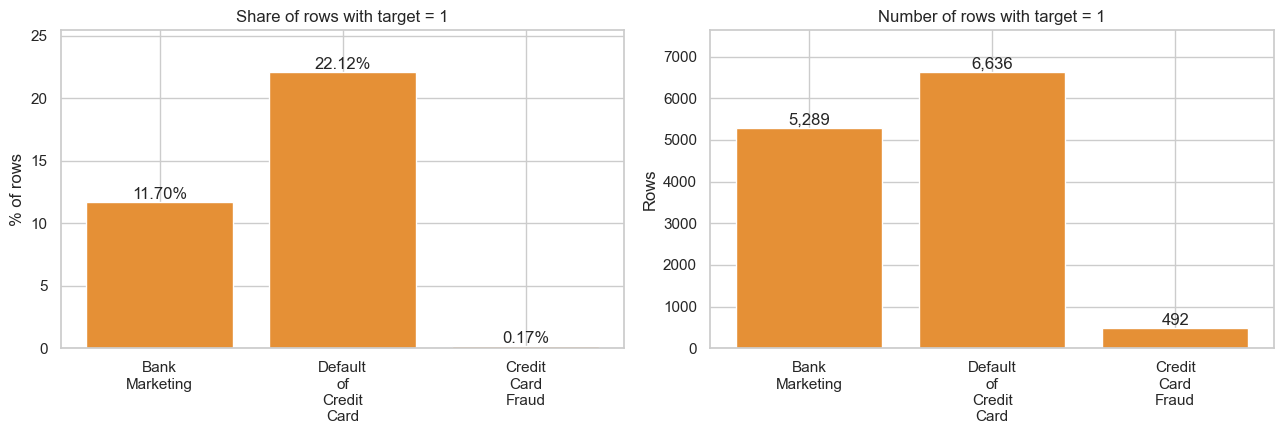

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
names = list(datasets)
short = [n.replace(' ', '\n') for n in names]
share = [100 * datasets[n].y.mean() for n in names]
axes[0].bar(short, share, color=COL['pos'])
for i, v in enumerate(share): axes[0].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=12)
axes[0].set(title='Share of rows with target = 1', ylabel='% of rows'); axes[0].set_ylim(0, max(share) * 1.15)
n1 = [int(datasets[n].y.sum()) for n in names]
axes[1].bar(short, n1, color=COL['pos'])
for i, v in enumerate(n1): axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=12)
axes[1].set(title='Number of rows with target = 1', ylabel='Rows'); axes[1].set_ylim(0, max(n1) * 1.15)
fig.tight_layout(); savefig('01_class_imbalance')

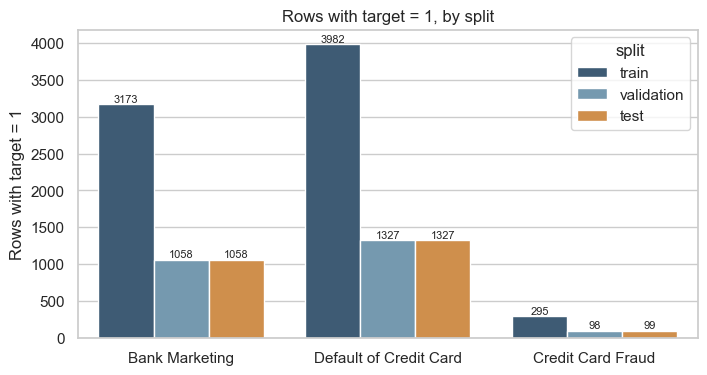

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sa = split_audit.reset_index()
sns.barplot(data=sa, x='dataset', y='target_1_rows', hue='split', ax=ax, palette=['#355C7D', '#6C9BB8', '#E59036'])
ax.set(title='Rows with target = 1, by split', ylabel='Rows with target = 1', xlabel='')
for c in ax.containers: ax.bar_label(c, fmt='%d', fontsize=8)
savefig('02_split_target1')

## 4. Data characteristics for GAN selection
The architecture's selection rules depend on column-type mix, size, imbalance and whether a defensible entity-plus-time structure exists. This table records the facts; the interpretation is in the notes after each dataset's section. A column is counted as *discrete-coded* if it is numeric with at most 15 distinct values.

In [8]:
chars = []
for name, d in datasets.items():
    tr = train_sets[name]; feats = tr.drop(columns='y')
    obj = feats.select_dtypes(exclude='number').columns
    num = feats.select_dtypes(include='number').columns
    coded = [c for c in num if feats[c].nunique() <= 15]
    cont = [c for c in num if c not in coded]
    skew = feats[cont].skew().abs()
    chars.append(pd.Series({
        'rows': len(d), 'categorical (object)': len(obj), 'discrete-coded numeric': len(coded),
        'continuous numeric': len(cont), 'continuous with |skew|>2': int((skew > 2).sum()),
        'missing cells (raw)': int(d.isna().sum().sum()),
        'entity id present': {'Bank Marketing': 'no', 'Default of Credit Card': 'no (row = customer)', 'Credit Card Fraud': 'no'}[name],
        'time index': {'Bank Marketing': 'month + day only, no year', 'Default of Credit Card': '6 monthly columns (wide)', 'Credit Card Fraud': 'Time = seconds over 2 days'}[name],
    }, name=name))
table(pd.DataFrame(chars).T, 'data_characteristics', round=False)

,Bank Marketing,Default of Credit Card,Credit Card Fraud
rows,45211,30000,284807
categorical (object),9,0,0
discrete-coded numeric,0,9,0
continuous numeric,7,14,30
continuous with |skew|>2,5,12,15
missing cells (raw),52124,0,0
entity id present,no,no (row = customer),no
time index,"month + day only, no year",6 monthly columns (wide),Time = seconds over 2 days


## 5. Quality profile (training split)
Types, cardinality, missing values, exact duplicates, out-of-range or undocumented values, and duplicate overlap across splits.

In [9]:
quality_rows = []
for name, d in datasets.items():
    tr = train_sets[name]; feats = [c for c in d.columns if c != 'y']
    hashes = {k: set(pd.util.hash_pandas_object(d.loc[ids], index=False)) for k, ids in splits[name].items()}
    # full-dataset duplicate counts too, since fraud duplicates are known to matter
    quality_rows.append(pd.Series({
        'train_rows': len(tr),
        'train_missing_cells': int(tr.isna().sum().sum()),
        'full_exact_duplicate_rows': int(d.duplicated().sum()),
        'train_exact_duplicate_rows': int(tr.duplicated().sum()),
        'train_predictor_duplicates': int(tr[feats].duplicated().sum()),
        'train_dups_with_conflicting_label': int(tr[feats].duplicated(keep=False).sum() - tr.duplicated(keep=False).sum()),
        'row_values_shared_train_validation': len(hashes['validation'] & hashes['train']),
        'row_values_shared_train_test': len(hashes['test'] & hashes['train']),
    }, name=name))
table(pd.DataFrame(quality_rows).T, 'quality_profile', round=False)

,Bank Marketing,Default of Credit Card,Credit Card Fraud
train_rows,27126,18000,170884
train_missing_cells,31358,0,0
full_exact_duplicate_rows,0,35,1081
train_exact_duplicate_rows,0,14,408
train_predictor_duplicates,0,24,408
train_dups_with_conflicting_label,0,18,0
row_values_shared_train_validation,0,6,266
row_values_shared_train_test,0,9,231


Duplicate rows matter for GANs and for evaluation. A duplicated row can land in both train and test after a random split, which inflates apparent performance and makes the privacy check (distance to closest record) look worse than it should. The last two rows count distinct row values shared across splits.

## 6. Default of Credit Card Clients
Detailed EDA for the moderate-imbalance, time-structured dataset. The documentation lists categories that the data does not always follow, so the code audits the codes before any recoding.

In [10]:
tr = train_sets['Default of Credit Card']
print(f'Train rows: {len(tr):,}; default rate: {tr.y.mean():.2%}')
coded = ['SEX', 'EDUCATION', 'MARRIAGE'] + [f'PAY_{i}' for i in range(1, 7)]
rows = []
for c in coded:
    vc = tr[c].value_counts().sort_index()
    rows.append(pd.Series({'values_observed': list(vc.index), 'counts': list(vc.values)}, name=c))
table(pd.DataFrame(rows), 'default_code_audit', round=False)
print('Documented: EDUCATION 1-4 (5, 6 unknown), MARRIAGE 1-3, PAY_x -1 (paid duly), 1-9 (months late).')
print('Observed but undocumented -> EDUCATION 0/5/6, MARRIAGE 0, PAY_x -2 and 0. Kept as-is here; recoding is a pre-processing decision.')
undoc = {'EDUCATION': tr.EDUCATION.isin([0, 5, 6]).sum(), 'MARRIAGE': tr.MARRIAGE.eq(0).sum(),
         'PAY_1 in {-2,0}': tr.PAY_1.isin([-2, 0]).sum()}
print({k: f'{v:,} ({v/len(tr):.1%})' for k, v in undoc.items()})

Train rows: 18,000; default rate: 22.12%


,values_observed,counts
SEX,"[1, 2]","[7179, 10821]"
EDUCATION,"[0, 1, 2, 3, 4, 5, 6]","[12, 6338, 8438, 2928, 72, 181, 31]"
MARRIAGE,"[0, 1, 2, 3]","[37, 8173, 9594, 196]"
PAY_1,"[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]","[1666, 3383, 8805, 2245, 1635, 184, 41, 12, 9,..."
PAY_2,"[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7]","[2275, 3626, 9406, 20, 2381, 197, 56, 16, 9, 14]"
PAY_3,"[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]","[2455, 3529, 9488, 2, 2289, 144, 49, 12, 16, 1..."
PAY_4,"[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]","[2611, 3402, 9860, 1, 1919, 110, 44, 23, 1, 28..."
PAY_5,"[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]","[2760, 3324, 10136, 1570, 115, 56, 9, 3, 26, 1]"
PAY_6,"[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]","[2967, 3422, 9722, 1699, 118, 35, 6, 7, 23, 1]"


Documented: EDUCATION 1-4 (5, 6 unknown), MARRIAGE 1-3, PAY_x -1 (paid duly), 1-9 (months late).
Observed but undocumented -> EDUCATION 0/5/6, MARRIAGE 0, PAY_x -2 and 0. Kept as-is here; recoding is a pre-processing decision.
{'EDUCATION': '224 (1.2%)', 'MARRIAGE': '37 (0.2%)', 'PAY_1 in {-2,0}': '10,471 (58.2%)'}


,n,target_1,rate,ci_low,ci_high,low_support
SEX,,,,,,
1,7179,1753,0.2442,0.2344,0.2543,False
2,10821,2229,0.2060,0.1985,0.2137,False


,n,target_1,rate,ci_low,ci_high,low_support
EDUCATION,,,,,,
0,12,0,0.0000,0.0000,0.2425,True
1,6338,1227,0.1936,0.1841,0.2035,False
2,8438,2020,0.2394,0.2304,0.2486,False
3,2928,717,0.2449,0.2296,0.2608,False
4,72,3,0.0417,0.0143,0.1155,True
5,181,11,0.0608,0.0343,0.1055,True
6,31,4,0.1290,0.0513,0.2885,True


,n,target_1,rate,ci_low,ci_high,low_support
MARRIAGE,,,,,,
0,37,4,0.1081,0.0429,0.2471,True
1,8173,1910,0.2337,0.2246,0.2430,False
2,9594,2012,0.2097,0.2017,0.2180,False
3,196,56,0.2857,0.2271,0.3526,False


,n,target_1,rate,ci_low,ci_high,low_support
age_band,,,,,,
<25,1612,450,0.2792,0.2578,0.3016,False
25–34,7865,1609,0.2046,0.1958,0.2136,False
35–44,5409,1175,0.2172,0.2064,0.2284,False
45–54,2502,592,0.2366,0.2204,0.2537,False
55+,612,156,0.2549,0.2220,0.2909,False


,n,target_1,rate,ci_low,ci_high,low_support
limit_band,,,,,,
"(9999.999, 50000.0]",4585,1474,0.3215,0.3081,0.3351,False
"(50000.0, 100000.0]",2885,742,0.2572,0.2416,0.2735,False
"(100000.0, 180000.0]",3658,717,0.1960,0.1835,0.2092,False
"(180000.0, 270000.0]",3319,574,0.1729,0.1605,0.1862,False
"(270000.0, 1000000.0]",3553,475,0.1337,0.1229,0.1453,False


,n,target_1,rate,ci_low,ci_high,low_support
PAY_1,,,,,,
-2,1666,201,0.1206,0.1059,0.1372,False
-1,3383,573,0.1694,0.1571,0.1824,False
0,8805,1124,0.1277,0.1208,0.1348,False
1,2245,752,0.3350,0.3157,0.3548,False
2,1635,1139,0.6966,0.6739,0.7184,False
3,184,140,0.7609,0.6943,0.8168,False
4,41,30,0.7317,0.5807,0.8431,True
5,12,5,0.4167,0.1933,0.6805,True
6,9,6,0.6667,0.3542,0.8794,True


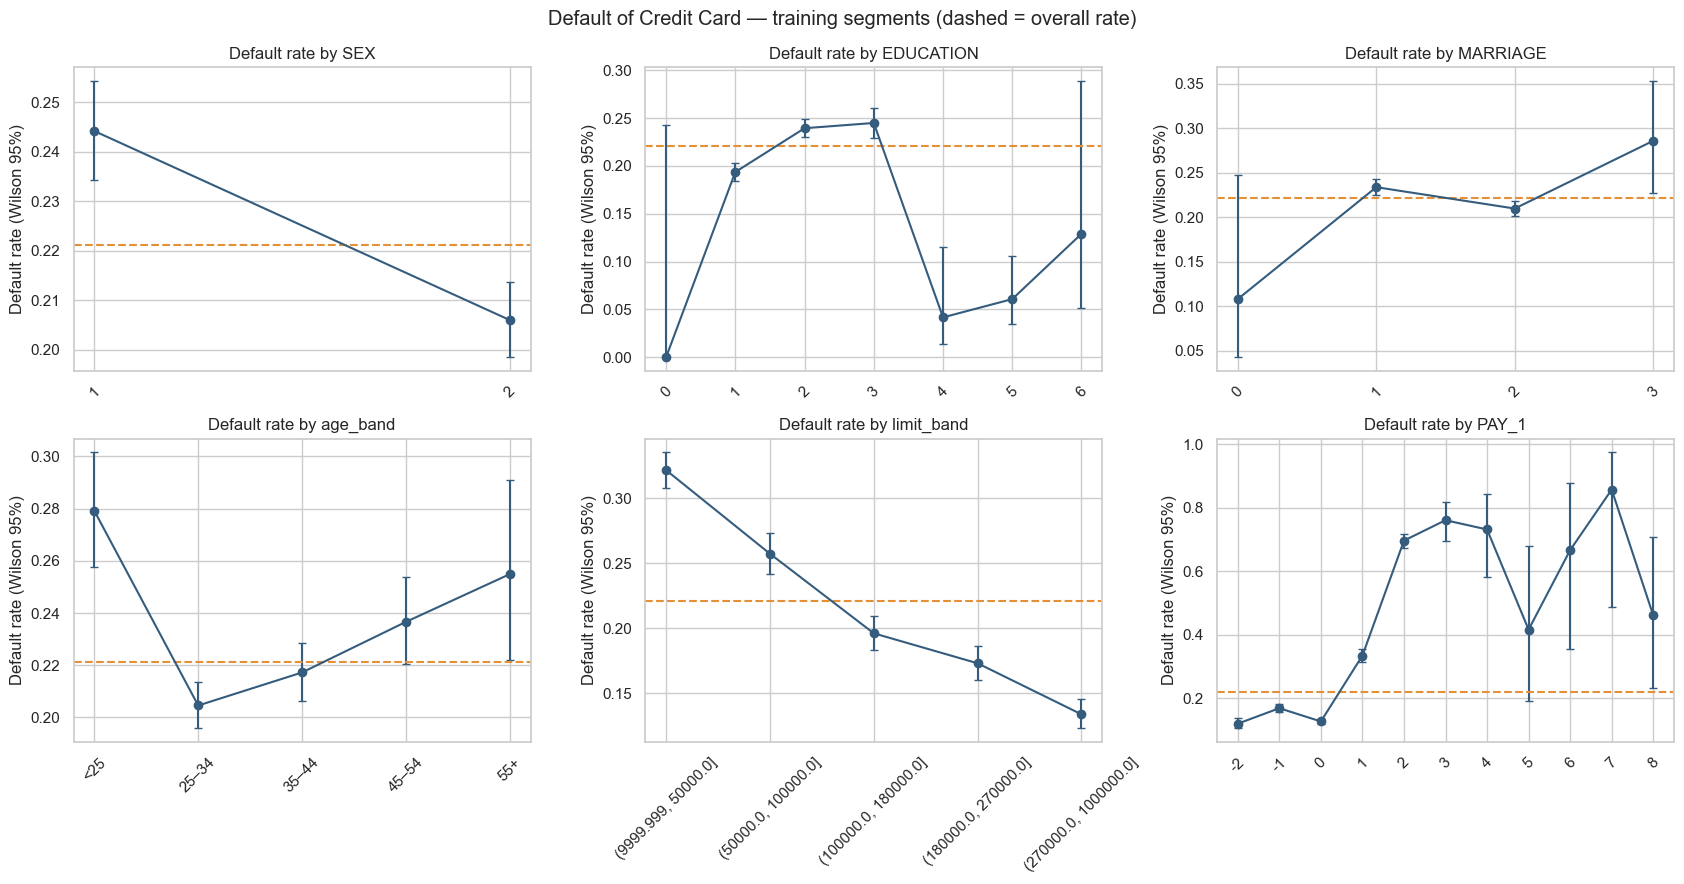

In [11]:
tr = tr.copy()
tr['age_band'] = pd.cut(tr.AGE, [0, 25, 35, 45, 55, np.inf], right=False, labels=['<25', '25–34', '35–44', '45–54', '55+'])
tr['limit_band'] = pd.qcut(tr.LIMIT_BAL, 5, duplicates='drop')
seg = {c: segments(tr, c) for c in ['SEX', 'EDUCATION', 'MARRIAGE', 'age_band', 'limit_band', 'PAY_1']}
for c, g in seg.items(): table(g, f'default_segment_{c}')
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, (c, g) in zip(axes.flat, seg.items()):
    g = g.copy(); g.index = g.index.astype(str)
    ax.errorbar(g.index, g.rate, yerr=[g.rate - g.ci_low, g.ci_high - g.rate], fmt='o-', color=COL['neg'], capsize=3)
    ax.axhline(tr.y.mean(), color=COL['pos'], ls='--'); ax.set(title=f'Default rate by {c}', ylabel='Default rate (Wilson 95%)')
    ax.tick_params(axis='x', rotation=45)
fig.suptitle('Default of Credit Card — training segments (dashed = overall rate)'); fig.tight_layout(); savefig('03_default_segments')

,count,mean,std,min,1%,50%,99%,max
LIMIT_BAL,18000.0,167730.6667,129767.6500,10000.0,10000.00,140000.0,500000.00,1000000.0
AGE,18000.0,35.4225,9.1558,21.0,22.00,34.0,60.00,75.0
BILL_AMT1,18000.0,51473.4103,73956.5107,-165580.0,-73.01,22344.5,352736.26,964511.0
BILL_AMT2,18000.0,49538.1281,71646.0645,-69777.0,-150.00,21226.5,337765.29,983931.0
BILL_AMT3,18000.0,47318.3559,69066.9500,-61506.0,-150.00,20074.0,324327.51,855086.0
BILL_AMT4,18000.0,43623.1054,64747.2224,-46627.0,-202.00,18991.0,307983.74,891586.0
BILL_AMT5,18000.0,40562.4361,61102.6635,-81334.0,-212.01,18165.5,285922.27,927171.0
BILL_AMT6,18000.0,39040.3611,59684.9858,-209051.0,-320.05,17143.0,278118.43,961664.0
PAY_AMT1,18000.0,5685.1994,16898.3416,0.0,0.00,2138.5,68000.13,873552.0
PAY_AMT2,18000.0,5940.2873,21311.1642,0.0,0.00,2021.0,75729.31,1215471.0


Negative bill amounts per month: {'BILL_AMT1': 354, 'BILL_AMT2': 389, 'BILL_AMT3': 371, 'BILL_AMT4': 390, 'BILL_AMT5': 393, 'BILL_AMT6': 425}
Zero payments per month (share): {'PAY_AMT1': 0.17, 'PAY_AMT2': 0.18, 'PAY_AMT3': 0.2, 'PAY_AMT4': 0.21, 'PAY_AMT5': 0.22, 'PAY_AMT6': 0.24}
Bill above credit limit (any month): 13.1%


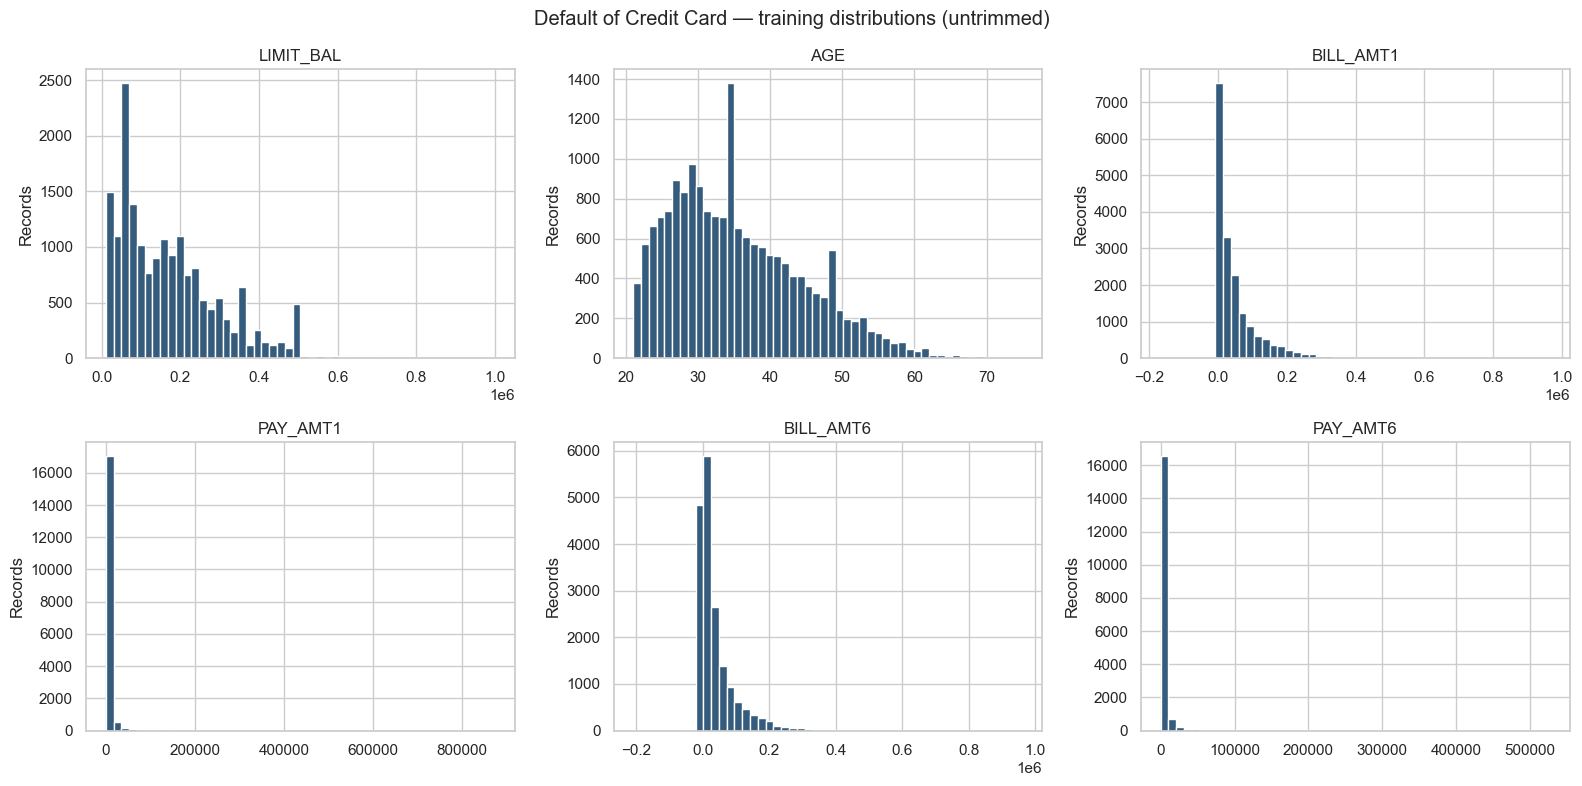

In [12]:
bill = [f'BILL_AMT{i}' for i in range(1, 7)]; pay = [f'PAY_AMT{i}' for i in range(1, 7)]; status = [f'PAY_{i}' for i in range(1, 7)]
num_view = tr[['LIMIT_BAL', 'AGE'] + bill + pay]
table(num_view.describe(percentiles=[.01, .5, .99]).T, 'default_numeric_summary')
print('Negative bill amounts per month:', {c: int((tr[c] < 0).sum()) for c in bill})
print('Zero payments per month (share):', {c: round(float((tr[c] == 0).mean()), 2) for c in pay})
print('Bill above credit limit (any month):', f"{(tr[bill].gt(tr.LIMIT_BAL, axis=0)).any(axis=1).mean():.1%}")
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flat, ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'BILL_AMT6', 'PAY_AMT6']):
    ax.hist(tr[c], bins=50, color=COL['neg']); ax.set(title=c, ylabel='Records')
fig.suptitle('Default of Credit Card — training distributions (untrimmed)'); fig.tight_layout(); savefig('04_default_distributions')

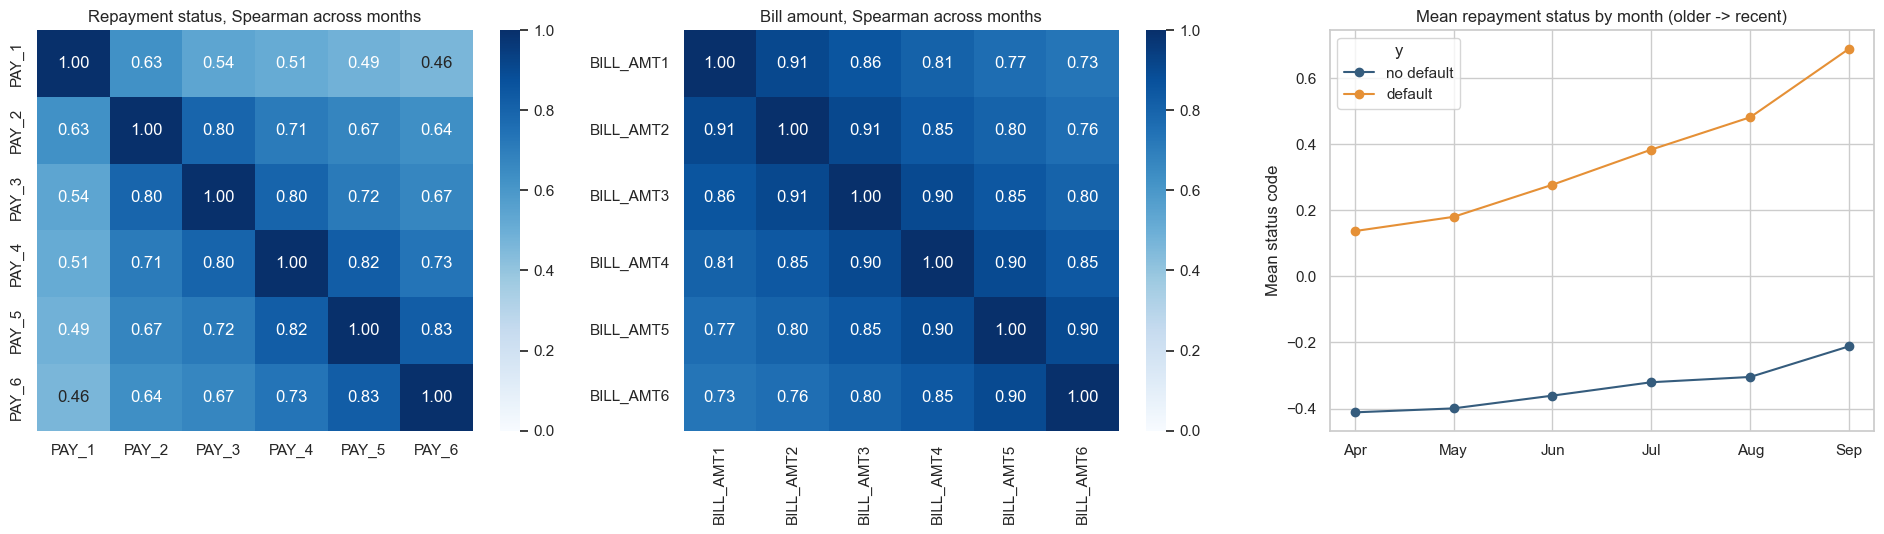

Mean adjacent-month bill correlation: 0.90
Each row is one customer with 6 monthly columns (wide). There is no customer id column and a single window per customer,
so the sequence length is 6 and the number of sequences equals the number of rows.


In [13]:
# Time structure: how persistent is each customer's history across the 6 months?
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
sns.heatmap(tr[status].corr(method='spearman'), annot=True, fmt='.2f', vmin=0, vmax=1, cmap='Blues', ax=axes[0]); axes[0].set_title('Repayment status, Spearman across months')
sns.heatmap(tr[bill].corr(method='spearman'), annot=True, fmt='.2f', vmin=0, vmax=1, cmap='Blues', ax=axes[1]); axes[1].set_title('Bill amount, Spearman across months')
mean_by = pd.DataFrame({m: tr.groupby('y')[f'PAY_{m}'].mean() for m in range(1, 7)}).rename(index={0: 'no default', 1: 'default'})
mean_by.columns = ['Sep', 'Aug', 'Jul', 'Jun', 'May', 'Apr']
mean_by.T[::-1].plot(marker='o', ax=axes[2], color=[COL['neg'], COL['pos']]); axes[2].set(title='Mean repayment status by month (older -> recent)', ylabel='Mean status code')
fig.tight_layout(); savefig('05_default_time_structure')
adj = np.mean([tr[f'BILL_AMT{i}'].corr(tr[f'BILL_AMT{i+1}'], method='spearman') for i in range(1, 6)])
print(f'Mean adjacent-month bill correlation: {adj:.2f}')
print('Each row is one customer with 6 monthly columns (wide). There is no customer id column and a single window per customer,')
print('so the sequence length is 6 and the number of sequences equals the number of rows.')

In [14]:
# Association of each feature with default (training only): Spearman for numerics.
assoc = tr[['LIMIT_BAL', 'AGE', 'SEX', 'EDUCATION', 'MARRIAGE'] + status + bill + pay].corrwith(tr.y, method='spearman').sort_values(key=abs, ascending=False)
table(assoc.to_frame('spearman_with_default'), 'default_spearman_with_target')
print('Redundancy: BILL_AMT1..6 mean pairwise |rho| =', round(float(tr[bill].corr(method='spearman').abs().values[np.triu_indices(6, 1)].mean()), 2))

,spearman_with_default
PAY_1,0.2993
PAY_2,0.2251
PAY_3,0.2056
PAY_4,0.1868
LIMIT_BAL,-0.1742
PAY_5,0.1678
PAY_AMT1,-0.1603
PAY_6,0.1538
PAY_AMT2,-0.1481
PAY_AMT3,-0.1360


Redundancy: BILL_AMT1..6 mean pairwise |rho| = 0.84


## 7. Credit Card Fraud
Extreme imbalance, PCA-transformed features `V1`–`V28`, and the raw `Time` and `Amount`. The questions here are specific to the PCA issue Kyle raised in the meeting: how GAN-friendly are the components, and which fidelity checks stop being informative?

In [15]:
tr = train_sets['Credit Card Fraud']
V = [f'V{i}' for i in range(1, 29)]
print(f'Train rows: {len(tr):,}; target = 1 rows (frauds): {int(tr.y.sum())} ({tr.y.mean():.3%}); imbalance {int((1-tr.y).sum()/tr.y.sum())}:1')
print('Time monotonic in file order:', bool(fraud.Time.is_monotonic_increasing), '| span (hours):', round(float(fraud.Time.max()/3600), 1))
table(tr[['Time', 'Amount']].describe(percentiles=[.01, .5, .99]).T, 'fraud_time_amount_summary')
print('Zero-amount transactions:', int((tr.Amount == 0).sum()), '| fraud among them:', int(tr.loc[tr.Amount == 0, 'y'].sum()))

Train rows: 170,884; target = 1 rows (frauds): 295 (0.173%); imbalance 578:1
Time monotonic in file order: True | span (hours): 48.0


,count,mean,std,min,1%,50%,99%,max
Time,170884.0,94939.3729,47506.7122,0.0,2363.66,84907.50,170513.1700,172792.00
Amount,170884.0,88.4294,255.4363,0.0,0.12,22.05,1014.4684,25691.16


Zero-amount transactions: 1068 | fraud among them: 15


V1-V28 pairwise |Pearson| (train): mean 0.0033, max 0.038


Largest |corr| of any V with Time or Amount: {'Time': 0.42, 'Amount': 0.54}


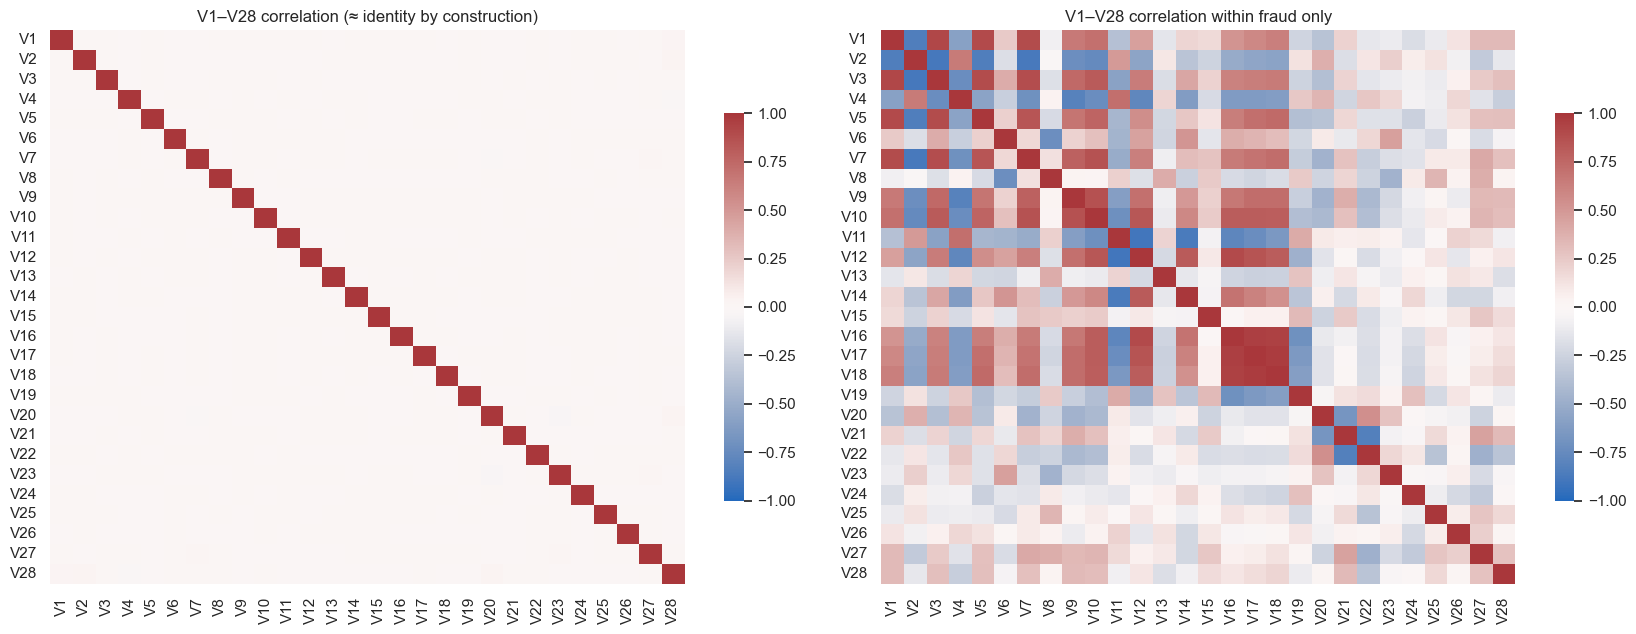

Mean |corr| among V within fraud class only: 0.312


In [16]:
# Are the V features really uncorrelated? (PCA components are orthogonal on the full data.)
cm = tr[V].corr()
off = cm.values[np.triu_indices(28, 1)]
print(f'V1-V28 pairwise |Pearson| (train): mean {np.abs(off).mean():.4f}, max {np.abs(off).max():.3f}')
cm_all = pd.concat([tr[V], tr[['Time', 'Amount']]], axis=1).corr()
print('Largest |corr| of any V with Time or Amount:', cm_all.loc[V, ['Time', 'Amount']].abs().max().round(2).to_dict())
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
sns.heatmap(cm, vmin=-1, vmax=1, cmap='vlag', ax=axes[0], cbar_kws={'shrink': .7}); axes[0].set_title('V1–V28 correlation (≈ identity by construction)')
fraud_cm = tr.loc[tr.y == 1, V].corr()
sns.heatmap(fraud_cm, vmin=-1, vmax=1, cmap='vlag', ax=axes[1], cbar_kws={'shrink': .7}); axes[1].set_title('V1–V28 correlation within fraud only')
fig.tight_layout(); savefig('06_fraud_v_correlation')
print('Mean |corr| among V within fraud class only:', round(float(np.abs(fraud_cm.values[np.triu_indices(28, 1)]).mean()), 3))

,skew,excess_kurtosis,std,std_mean_diff_fraud_vs_legit,ks_stat
feature,,,,,
V14,-2.0361,25.4276,0.9581,-2.2211,0.8490
V10,0.9909,34.5770,1.0889,-1.6241,0.8193
V12,-2.3830,22.3456,1.0003,-1.8299,0.7812
V4,0.6923,2.7812,1.4150,2.0758,0.7728
V17,-3.9512,96.3693,0.8491,-1.3866,0.7620
V11,0.3694,1.8512,1.0212,1.8403,0.7472
V3,-2.3805,30.6520,1.5193,-1.3714,0.7039
V16,-1.1379,11.5679,0.8765,-1.5159,0.7013
V7,4.0829,594.3281,1.2467,-1.0976,0.6629


Most class-separating components (KS): ['V14', 'V10', 'V12', 'V4', 'V17', 'V11', 'V3', 'V16']
Components with |skew|>2: 14 | excess kurtosis > 10: 17 of 28


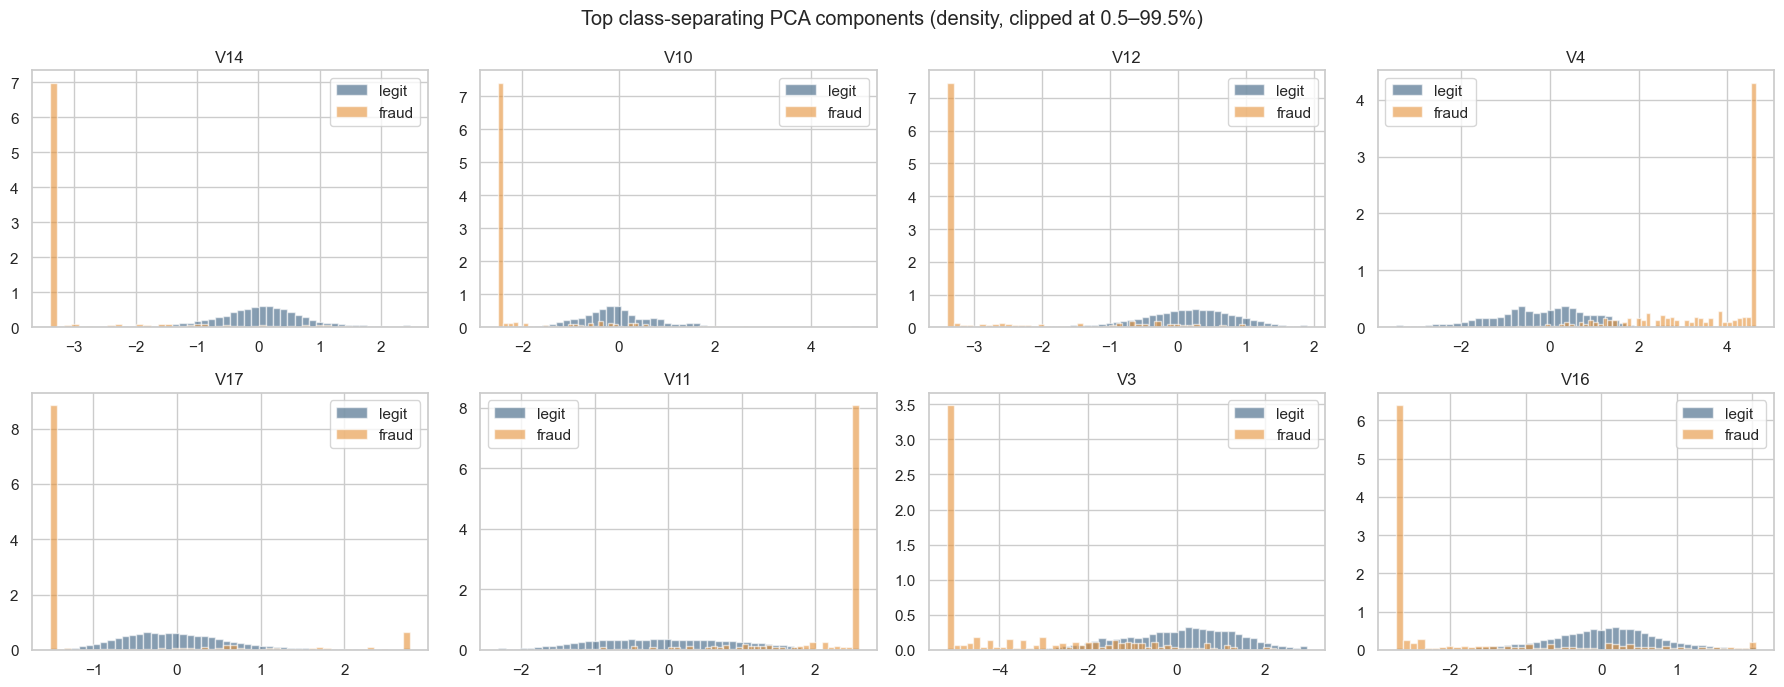

In [17]:
# Shape of each component: skew/kurtosis, and how well each separates the classes.
rows = []
for c in V + ['Amount', 'Time']:
    a, b = tr.loc[tr.y == 0, c], tr.loc[tr.y == 1, c]
    smd = (b.mean() - a.mean()) / np.sqrt((a.var() + b.var()) / 2)
    rows.append({'feature': c, 'skew': tr[c].skew(), 'excess_kurtosis': tr[c].kurt(), 'std': tr[c].std(),
                 'std_mean_diff_fraud_vs_legit': smd, 'ks_stat': ks_2samp(a, b).statistic})
fshape = pd.DataFrame(rows).set_index('feature')
table(fshape.sort_values('ks_stat', ascending=False), 'fraud_feature_shape_and_separation')
top = fshape.loc[V].ks_stat.sort_values(ascending=False).index[:8]
print('Most class-separating components (KS):', list(top))
print('Components with |skew|>2:', int((fshape.loc[V, 'skew'].abs() > 2).sum()), '| excess kurtosis > 10:', int((fshape.loc[V, 'excess_kurtosis'] > 10).sum()), 'of 28')
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.flat, top):
    for lab, k in [('legit', 0), ('fraud', 1)]:
        v = tr.loc[tr.y == k, c]; lo, hi = tr[c].quantile([.005, .995])
        ax.hist(v.clip(lo, hi), bins=50, density=True, alpha=.6, label=lab, color=COL['neg'] if k == 0 else COL['pos'])
    ax.set_title(c); ax.legend()
fig.suptitle('Top class-separating PCA components (density, clipped at 0.5–99.5%)'); fig.tight_layout(); savefig('07_fraud_top_components')

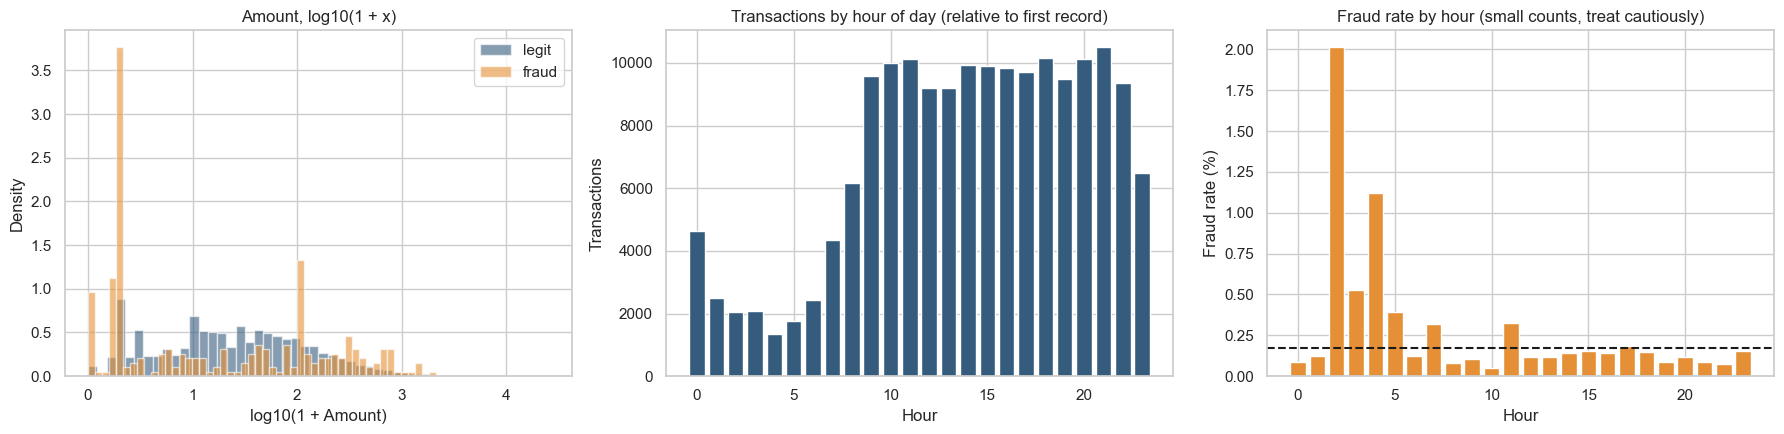

,n,target_1,rate,ci_low,ci_high,low_support
amt_band,,,,,,
≤1,18206,115,0.0063,0.0053,0.0076,False
1–10,41719,38,0.0009,0.0007,0.0012,False
10–50,54658,35,0.0006,0.0005,0.0009,False
50–200,38971,54,0.0014,0.0011,0.0018,False
200–1000,15581,48,0.0031,0.0023,0.0041,False
1000+,1749,5,0.0029,0.0012,0.0067,True


Fraud median amount: 8.0 | legit median amount: 22.06


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for k, lab in [(0, 'legit'), (1, 'fraud')]:
    axes[0].hist(np.log10(tr.loc[tr.y == k, 'Amount'] + 1), bins=50, density=True, alpha=.6, label=lab, color=COL['neg'] if k == 0 else COL['pos'])
axes[0].set(title='Amount, log10(1 + x)', xlabel='log10(1 + Amount)', ylabel='Density'); axes[0].legend()
hour = (tr.Time // 3600).astype(int) % 24
hr = pd.DataFrame({'hour': hour, 'y': tr.y}).groupby('hour').y.agg(['size', 'sum', 'mean'])
axes[1].bar(hr.index, hr['size'], color=COL['neg']); axes[1].set(title='Transactions by hour of day (relative to first record)', xlabel='Hour', ylabel='Transactions')
axes[2].bar(hr.index, 100 * hr['mean'], color=COL['pos']); axes[2].axhline(100 * tr.y.mean(), color='k', ls='--')
axes[2].set(title='Fraud rate by hour (small counts, treat cautiously)', xlabel='Hour', ylabel='Fraud rate (%)')
fig.tight_layout(); savefig('08_fraud_amount_time')
amt_seg = segments(tr.assign(amt_band=pd.cut(tr.Amount, [-1, 1, 10, 50, 200, 1000, np.inf], labels=['≤1', '1–10', '10–50', '50–200', '200–1000', '1000+'])), 'amt_band')
table(amt_seg, 'fraud_segment_amount_band')
print('Fraud median amount:', tr.loc[tr.y == 1, 'Amount'].median(), '| legit median amount:', tr.loc[tr.y == 0, 'Amount'].median())

In [19]:
# Duplicates and how they interact with the split (full dataset, since a few hundred rows decide the picture).
dup_all = fraud.duplicated(keep=False)
print('Rows in an exact-duplicate group (full data):', int(dup_all.sum()), '| duplicate excess rows:', int(fraud.duplicated().sum()))
print('Duplicate excess rows that are fraud:', int((fraud.duplicated() & fraud.y.eq(1)).sum()))
h = pd.util.hash_pandas_object(fraud, index=False)
sets = {k: set(h.loc[ids]) for k, ids in splits['Credit Card Fraud'].items()}
print('Row values shared across splits:', {f'{a}-{b}': len(sets[a] & sets[b]) for a, b in [('train', 'validation'), ('train', 'test'), ('validation', 'test')]})

Rows in an exact-duplicate group (full data): 1854 | duplicate excess rows: 1081


Duplicate excess rows that are fraud: 19
Row values shared across splits: {'train-validation': 266, 'train-test': 231, 'validation-test': 96}


## 8. Bank Marketing — shared overview only
The detailed bank EDA is in `Bank_Marketing_EDA.ipynb`. Here it only supplies the same imbalance and structure numbers as the other two datasets, so the three are comparable.

In [20]:
tr = train_sets['Bank Marketing']
print(f'Train rows: {len(tr):,}; target = 1 rows: {int(tr.y.sum()):,} ({tr.y.mean():.2%})')
bank_seg = segments(tr, 'job'); table(bank_seg.sort_values('rate', ascending=False).head(5), 'bank_top_job_segments')
print('Range of target = 1 share across job groups:', f'{bank_seg.rate.min():.1%} to {bank_seg.rate.max():.1%}')

Train rows: 27,126; target = 1 rows: 3,173 (11.70%)


,n,target_1,rate,ci_low,ci_high,low_support
job,,,,,,
student,583,173,0.2967,0.2611,0.3351,False
retired,1367,299,0.2187,0.1976,0.2414,False
unemployed,790,121,0.1532,0.1297,0.1800,False
management,5559,784,0.1410,0.1321,0.1504,False
admin.,3146,390,0.1240,0.1129,0.1359,False


Range of target = 1 share across job groups: 7.3% to 29.7%


## 9. Cross-dataset summary
One row per dataset: how imbalanced it is and how many target = 1 rows each split has.

In [21]:
table(imbalance[['rows', 'target=1 share (%)', 'imbalance (0s per 1)', 'target=1 rows in train',
                 'target=1 rows in validation', 'target=1 rows in test']].sort_values('target=1 share (%)', ascending=False),
      'cross_dataset_summary', round=False)

,rows,target=1 share (%),imbalance (0s per 1),target=1 rows in train,target=1 rows in validation,target=1 rows in test
Default of Credit Card,30000.0,22.120000,3.520796,3982.0,1327.0,1327.0
Bank Marketing,45211.0,11.698480,7.548119,3173.0,1058.0,1058.0
Credit Card Fraud,284807.0,0.172749,577.876016,295.0,98.0,99.0
